In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("ACCIDENTS_GU_BCN_2013.csv", encoding= 'latin-1')
 
data['Date'] = '2013-'+data['Mes de any'].apply(lambda x : str(x)) + '-' + data['Dia de mes'].apply(lambda x : str(x))
data['Date'] = pd.to_datetime(data['Date'])
accidents = data.groupby(['Date']).size()
print("Mean:", accidents.mean())

Mean: 25.90958904109589


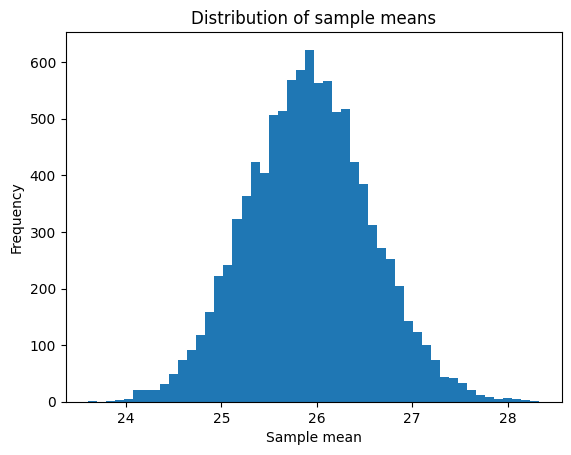

In [6]:
# population
df = accidents.to_frame()
N_test = 10000
elements = 200
# mean array of samples
means = [0] * N_test
# sample generation
for i in range(N_test):
    rows = np.random.choice(df.index.values, elements)
    sampled_df = df.loc[rows]
    means[i] = sampled_df.mean()

samples = np.random.choice(df.index.values, size=(N_test, elements))
means = df.loc[samples.flatten(), df.columns[0]].values.reshape(N_test, elements).mean(axis=1)

plt.hist(means, bins=50)
plt.xlabel('Sample mean')
plt.ylabel('Frequency')
plt.title('Distribution of sample means')
plt.show()